# Problem: quantum

Two real spectra, and the Schrödinger equation solved directly so the laws
behind them can be recovered where the answer is known exactly.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display
from physprior.viz import plots as P
from physprior.io import load_table, load_json
from physprior.config import get_settings
from physprior.benchmark.protocol import fit_arm

RESULTS = get_settings().results_dir
P.use_style()
pd.set_option("display.width", 160, "display.max_columns", 60)

def gif(path, width=560, caption=""):
    "Show an animation from figures/ without embedding it in the notebook."
    cap = f"<div style='color:#52514e;font-size:90%'>{caption}</div>" if caption else ""
    return HTML(f"<img src='../figures/{path}' width='{width}'>{cap}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 1 · Solve the Schrödinger equation

$$-\tfrac12 \psi'' + V(x)\,\psi = E\,\psi$$

on a uniform grid with $\psi = 0$ at the ends, diagonalised directly
(`scipy.linalg.eigh_tridiagonal`). Units are $\hbar = m = 1$, so the answers
are the textbook ones.

In [2]:
m = load_json("quantum", "problem_meta")
sp = m["simulations"]["spectra"]
rows = [{"system": k, "law": v["law"], "max rel error": v["max_rel_error"],
         "E_0": v["energy"][0], "E_0 exact": v["exact"][0]} for k,v in sp.items()]
display(pd.DataFrame(rows))
for k in sp:
    display(gif(f"quantum/eigenstates_{k}.png", 540))

,system,law,max rel error,E_0,E_0 exact
0,harmonic,E_n = (n + 1/2) omega,0.000010,0.499999,0.500000
1,hydrogen,E_n = -1/(2 n^2) Hartree,0.000130,-0.499935,-0.500000
2,infinite_well,E_n = n^2 pi^2 / (2 L^2),0.000005,4.934802,4.934802


### Its error is measured, not assumed

Second-order finite differences: halving `dx` should quarter the error.

In [3]:
display(pd.DataFrame(m["simulations"]["grid_convergence"]))
display(pd.DataFrame(m["simulations"]["box_convergence"]))
display(pd.DataFrame(m["simulations"]["r_min_sweep"]))

,E0,E0_exact,dx,max_rel_error,n_grid,error_ratio_vs_coarser
0,0.499928,0.5,0.048096,0.000802,500,NaN
1,0.499982,0.5,0.024024,0.000200,1000,4.010457
2,0.499995,0.5,0.012006,0.000050,2000,4.004611
3,0.499999,0.5,0.006002,0.000012,4000,4.002152
4,0.500000,0.5,0.003000,0.000003,8000,4.001039


,E_last,E_last_exact,max_rel_error,r_max_bohr,worst_level_n
0,-0.004663,-0.007812,0.403158,100.0,8
1,-0.007812,-0.007812,0.000016,200.0,8
2,-0.007812,-0.007812,0.000029,400.0,1
3,-0.007812,-0.007812,0.000130,900.0,1


,max_rel_err_n160000,max_rel_err_n40000,max_rel_err_n80000,r_min
0,0.000012,0.000130,0.000036,0.000001
1,0.000048,0.000166,0.000071,0.000010
2,0.000405,0.000517,0.000427,0.000100
3,0.003933,0.003995,0.003939,0.001000


The `r_min` sweep is the one worth pausing on: at `r_min = 1e-3` the hydrogen
error **stops responding to the grid entirely**. Refining `dx` does nothing,
because the limit is the inner boundary, not the step size.

## 2 · Tunnelling

Split-operator time evolution — unitary by construction, so the norm is a
machine-precision check rather than a tolerance.

In [4]:
tu = m["simulations"]["tunnelling"]
display(gif("quantum/tunnelling.gif", 640))
print(f"packet energy      : {tu['energy']:.3f}")
print(f"barrier height     : {tu['barrier_height']:.3f}  "
      f"-> classically allowed? {tu['classically_allowed']}")
print(f"transmitted        : {tu['transmission']:.4f}")
print(f"norm drift         : {tu['norm_drift']:.1e}   (unitary)")

packet energy      : 0.980
barrier height     : 1.200  -> classically allowed? False
transmitted        : 0.7349
norm drift         : 5.4e-15   (unitary)


## 3 · Recover the spectrum's law

Symbolic regression is handed nothing but `(n, E_n)` from the solver.

In [5]:
display(load_table("quantum","spectrum_laws"))
for r in m["discovery"]["spectrum_laws"]:
    print(f"[{r['system']:9s}] {r['law']}")
    print(f"    SR: {r['sr_expression']}")
    if r["exponent_found"] is not None:
        print(f"    exponent {r['exponent_found']:.6f} (expect {r['exponent_expected']})")
    else:
        print(f"    not a power law -- spacing {r['level_spacing']:.6f} "
              f"+- {r['level_spacing_std']:.1e}  (the oscillator is affine in n)")

,system,law,n_levels,solver_max_rel_error,sr_expression,scale,exponent_found,exponent_expected,exponent_error,level_spacing,level_spacing_std
0,well,E_n = n^2 pi^2 / (2 L^2),10,0.000005,(n**2 - 5.1084587e-8*(n**4 - n))*0.010000051,493.477682,1.999998,2.0,0.000002,54.282542,25.482940
1,harmonic,E_n = (n + 1/2) omega,10,0.000010,n*(0.10526405 + n*(-1.0496476e-7)) + 0.052632026,9.499909,NaN,NaN,NaN,0.999990,0.000005
2,hydrogen,E_n = -1/(2 n^2) Hartree,10,0.000130,-1.0001295/(n**2 + 0.00012947575),0.499935,-1.999944,-2.0,0.000056,0.054993,0.114969


[well     ] E_n = n^2 pi^2 / (2 L^2)
    SR: (n**2 - 5.1084587e-8*(n**4 - n))*0.010000051
    exponent 1.999998 (expect 2.0)
[harmonic ] E_n = (n + 1/2) omega
    SR: n*(0.10526405 + n*(-1.0496476e-7)) + 0.052632026
    not a power law -- spacing 0.999990 +- 5.2e-06  (the oscillator is affine in n)
[hydrogen ] E_n = -1/(2 n^2) Hartree
    SR: -1.0001295/(n**2 + 0.00012947575)
    exponent -1.999944 (expect -2.0)


The oscillator is the interesting one: `power_law_exponent` correctly returns
**nothing**, because `E = ω(n + ½)` is affine in `n`, not a power law. The
level *spacing* is the right statistic there, and it comes out at ω to 5×10⁻⁶.

## 4 · The real atom: NIST hydrogen levels

In [6]:
from physprior.problems.quantum import hydrogen
prob, hmeta = hydrogen.problem()
hmeta = {**hmeta, **load_json("quantum/hydrogen", "meta")}
f = fit_arm("physics", prob, np.arange(len(prob)), seed=11)
print(f"R fitted from the levels : {f.params['R']:.4f} +- {f.param_sigma['R']:.4f} cm^-1")
print(f"NIST ionisation limit    : {hmeta['ionisation_limit_icm']:.6f} cm^-1 (independent)")
print(f"Bohr (reduced-mass) R_H  : {hmeta['bohr_rydberg_H_icm']:.4f} cm^-1")
print(f"   fit vs NIST limit : {abs(f.params['R']-hmeta['ionisation_limit_icm'])/hmeta['ionisation_limit_icm']*1e9:.0f} ppb")
print(f"   limit vs Bohr     : {hmeta['limit_minus_bohr_ppm']:+.2f} ppm  <- QED + relativistic")
print("SR:", hmeta["headline"]["sr"]["law_check"])
display(gif("quantum/hydrogen/bohr_residual.png", 560))

R fitted from the levels : 109678.7774 +- 0.0002 cm^-1
NIST ionisation limit    : 109678.771743 cm^-1 (independent)
Bohr (reduced-mass) R_H  : 109677.5834 cm^-1
   fit vs NIST limit : 51 ppb
   limit vs Bohr     : +10.83 ppm  <- QED + relativistic
SR: {'coeff': 109682.4992639643, 'expression': '-0.22825128 - 1*(-1.3250389) + (-1*(-2.9354997e-6) - 1.0967906/n)/n', 'is_bohr_form': True, 'limit': 109678.76200007167, 'loglog_resid': 1.0138360298006038e-05, 'power': 2.000030023865405}


### The same QED, from the other direction

The simulation solves the *non-relativistic Coulomb problem* — precisely what
Bohr and Schrödinger predict. NIST measures the real atom. The difference is
not solver error and not a fitting artefact.

For this comparison to mean anything the solver has to be better than the
effect, so the levels are Richardson-extrapolated from two grids: 300 ppm → 4 ppm.

In [7]:
sv = m["discovery"]["schrodinger_vs_nist"]
print(f"solver error          : {sv['solver_max_rel_error_ppm']:.1f} ppm "
      f"(plain finite differences: {sv['solver_without_richardson_ppm']:.0f} ppm)")
print(f"simulation vs NIST    : {sv['mean_gap_ppm']:+.2f} ppm")
print(f"QED by fitting Bohr   : {sv['limit_minus_bohr_ppm']:+.2f} ppm")
print()
print("two routes to the same physics, agreeing within the solver's error.")
pd.DataFrame({"n": sv["n"][1:], "gap [ppm]": np.round(sv["gap_ppm_by_n"],2)})

solver error          : 4.0 ppm (plain finite differences: 43 ppm)
simulation vs NIST    : +15.36 ppm
QED by fitting Bohr   : +10.83 ppm

two routes to the same physics, agreeing within the solver's error.


,n,gap [ppm]
0,2.0,16.44
1,3.0,15.79
2,4.0,15.55
3,5.0,15.29
4,6.0,15.18
5,7.0,15.08
6,8.0,15.02
7,9.0,14.97
8,10.0,14.95


## 5 · COBE/FIRAS, and the law symbolic regression could *not* find

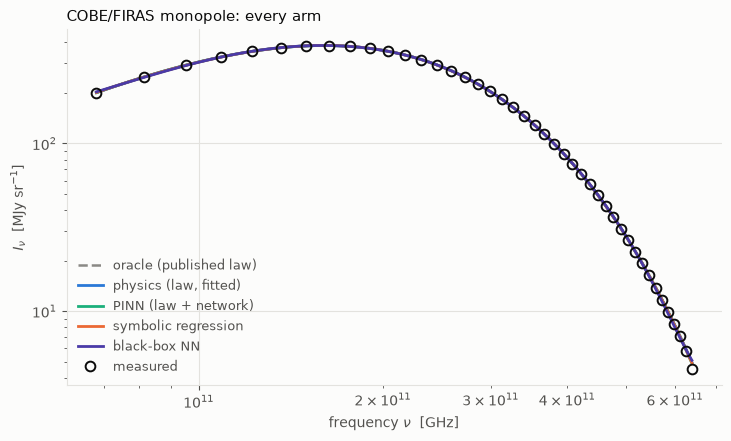

T = 2.725015 +- 0.000008 K  (Fixsen 2009: 2.72548 +- 0.00057)
chi2/dof = 1.074

SR on FIRAS: (nu + 0.07698194291844*(1.3383667 - nu)**2)**3*exp((1.5615451 - nu)/0.5149329)
  deviation from Planck INSIDE the band : 1.07%
  deviation from Planck OUTSIDE it      : 5918.7%


In [8]:
from physprior.problems.quantum import cmb
cprob, cmeta = cmb.problem()
cmeta = {**cmeta, **load_json("quantum/cmb", "meta")}
cfits = {a: fit_arm(a, cprob, np.arange(len(cprob)), seed=11)
         for a in ["oracle","physics","pinn","sr","nn"]}
P.fig_overview(cprob, cfits, logx=True, logy=True,
               title="COBE/FIRAS monopole: every arm"); plt.show()
from physprior.benchmark.metrics import chi2_reduced
cf = cfits["physics"]
print(f"T = {cf.params['T']:.6f} +- {cf.param_sigma['T']:.6f} K  "
      f"(Fixsen 2009: {cmeta['published_T_K']} +- {cmeta['published_T_err_K']})")
print(f"chi2/dof = {chi2_reduced(cprob.y, cf.predict(cprob.x), cprob.sigma, 1):.3f}")
print()
lc = cmeta["headline"]["sr"]["law_check"]
print("SR on FIRAS:", lc["expression"])
print(f"  deviation from Planck INSIDE the band : {lc['max_rel_dev_in_band']:.2%}")
print(f"  deviation from Planck OUTSIDE it      : {lc['max_rel_dev_outside']:.1%}")

SR fits the FIRAS band to a fraction of a per cent and the expression it
returns is **not** the Planck function. In that band `x = hν/kT` runs from 1.2
to 11.3 — almost all Wien, almost no Rayleigh-Jeans — and there `exp(−x)` and
`1/(exp(x) − 1)` are nearly the same function. The denominator is not
identifiable from the data.

The control keeps the method, the channel count and the noise fixed and only
widens the band downwards, on a synthetic spectrum where the answer is known.

In [9]:
ctrl = pd.DataFrame(json.load(open(RESULTS / "_band_control.json")))
display(ctrl[["x_min","max_rel_dev_in_band","max_rel_dev_outside","is_planck_form"]])
display(gif("quantum/cmb/band_coverage_control.png", 600))

,x_min,max_rel_dev_in_band,max_rel_dev_outside,is_planck_form
0,1.20,0.004067,32.442550,False
1,0.60,0.339044,354.853414,False
2,0.30,0.186661,20.094067,False
3,0.10,0.092426,10.564047,False
4,0.03,0.058957,0.583020,False


**In-band accuracy is anti-correlated with having found the law.** The
FIRAS-coverage run has the *best* in-band fit of the five and one of the worst
extrapolations. Fit quality on the observed range is not evidence that you
have discovered anything.